In [33]:
import pandas as pd

train_data_encoded = pd.read_csv('../data/train_encoded.csv')
test_data_encoded = pd.read_csv('../data/test_encoded.csv')

In [42]:
# We don't have to scale the values since MARS only cares about relative ordering and thresholds (like "is x > 15 or x < 60)

# Outlier is infuential to we cap them
# MARS uses least squares loss to fit the model.
# Least squares (minimizing sum of squared errors) is sensitive to outliers (big errors can dominate).
# find numeriacal value
X_train = train_data_encoded.drop('y',axis=1)
X_test = test_data_encoded
print(f'Existing data type are {X.dtypes.unique()}')
numerical_features = []
for f in X.columns:
    if X[f].dtype in ['int64','float64']:
        numerical_features.append(f)

# cap outliers
for f in numerical_features:
    lower = X_train[f].quantile(0.01)
    upper = X_train[f].quantile(0.99)
    X_train[f] = X_train[f].clip(lower, upper)
    
    lower = X_test[f].quantile(0.01)
    upper = X_test[f].quantile(0.99)
    X_test[f] = X_test[f].clip(lower, upper)
print('Outliers have been capped at 1st and 99th percentiles')

Existing data type are [dtype('int64') dtype('float64') dtype('bool')]
Outliers have been capped at 1st and 99th percentiles


In [ ]:
import os
import pickle
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.metrics import mean_squared_error
from pygam import LinearGAM, s # s defines a smooth function (usually a spline) that the model will fit for one feature.
from tqdm.auto import tqdm
import hashlib

# Load Data
X = X_train.values
y = train_data_encoded['y'].values
n_features = X.shape[1]

# Setup Cache
os.makedirs('./cache', exist_ok=True)
cache_path = './cache/gam_cache.pkl'

try:
    with open(cache_path, 'rb') as f:
        cache = pickle.load(f)
    print("Cache loaded from file.")
except FileNotFoundError:
    cache = {}
    print("No cache file found. Starting fresh.")

# Helper Functions
def params_to_hash(params):
    params_str = str(sorted(params.items()))
    return hashlib.md5(params_str.encode()).hexdigest()

# Define Parameter Grid
param_grid = {
    'lam': [0.1, 1, 50, 100], #	Controls how "wiggly" each smooth function can be
    'n_splines': [10, 20], # Controls how detailed the fit is — more splines = more flexibility
    'max_iter': [1000] # How long to let the fitting process continue
}
grid = list(ParameterGrid(param_grid))

# Manual Cross-Validation + Caching
results = []
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for params in tqdm(grid, desc="GAM Hyperparam tuning"):
    params_hash = params_to_hash(params)
    
    if params_hash in cache:
        avg_mse = cache[params_hash]
        print(f"Found cached result for {params} -> MSE: {avg_mse:.4f}")
    else:
        print(f'Processing {params}...')
        fold_mse = []
        for train_idx, val_idx in cv.split(X, y):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            # Build the GAM model with the correct number of splines
            terms = s(0, n_splines=params['n_splines'])
            for i in range(1, n_features):
                terms += s(i, n_splines=params['n_splines'])

            # Initialize GAM with specific lambda value
            gam = LinearGAM(terms, lam=params['lam'])
            gam.fit(X_tr, y_tr)

            # Predict and calculate validation MSE
            y_val_pred = gam.predict(X_val)
            mse = mean_squared_error(y_val, y_val_pred)
            fold_mse.append(mse)

        avg_mse = np.mean(fold_mse)
        cache[params_hash] = avg_mse
        print(f"Computed and cached result for {params} -> MSE: {avg_mse:.4f}")

    results.append({**params, 'avg_mse': avg_mse})

# Save Cache
with open(cache_path, 'wb') as f:
    pickle.dump(cache, f)
print("Cache updated and saved.")

# Summarize Results
results_df = pd.DataFrame(results).sort_values('avg_mse').reset_index(drop=True)
print("\nTop 5 GAM hyperparameter settings by CV-estimated MSE:")
print(results_df.head())

# Extract Best Parameters
best_params = results_df.iloc[0]
print(f"\nBest lam: {best_params.lam}, Best n_splines: {best_params.n_splines}, Best max_iter: {best_params.max_iter}")


Cache loaded from file.


GAM Hyperparam tuning: 100%|██████████| 6/6 [00:00<?, ?it/s]

Found cached result for {'lam': 0.1, 'max_iter': 1000, 'n_splines': 10} -> MSE: 5865.7316
Found cached result for {'lam': 0.1, 'max_iter': 1000, 'n_splines': 20} -> MSE: 6570.7792
Found cached result for {'lam': 1, 'max_iter': 1000, 'n_splines': 10} -> MSE: 5707.1764
Found cached result for {'lam': 1, 'max_iter': 1000, 'n_splines': 20} -> MSE: 6046.5637
Found cached result for {'lam': 100, 'max_iter': 1000, 'n_splines': 10} -> MSE: 5509.3129
Found cached result for {'lam': 100, 'max_iter': 1000, 'n_splines': 20} -> MSE: 5574.9059
Cache updated and saved.

Top 5 GAM hyperparameter settings by CV-estimated MSE:
     lam  max_iter  n_splines      avg_mse
0  100.0      1000         10  5509.312912
1  100.0      1000         20  5574.905851
2    1.0      1000         10  5707.176390
3    0.1      1000         10  5865.731563
4    1.0      1000         20  6046.563742

Best lam: 100.0, Best n_splines: 10.0, Best max_iter: 1000.0


Cross-Validation: 100%|██████████| 5/5 [00:47<00:00,  9.47s/it]



Final 5-Fold CV Evaluation:
Mean Squared Error (MSE): 5509.3129
R² Score: 0.7364


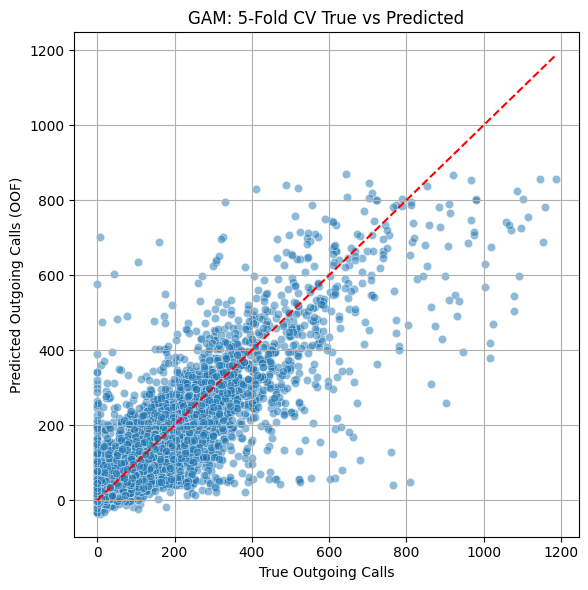

In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from pygam import LinearGAM, s
from tqdm.auto import tqdm

# Load Data
X = X 
y = y
n_features = X.shape[1]

# Best hyperparameters from tuning
best_lam = best_params.lam   
best_n_splines = best_params.n_splines  
best_max_iter = best_params.max_iter

# Setup 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store out-of-fold predictions
oof_preds = np.zeros_like(y, dtype=float)

# Loop through folds
for train_idx, val_idx in tqdm(kf.split(X,y), total=5, desc="Cross-Validation"):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # Build terms with best number of splines
    terms = s(0, n_splines=best_n_splines)
    for i in range(1, n_features):
        terms += s(i, n_splines=best_n_splines)

    # Initialize GAM
    gam = LinearGAM(terms, lam=best_lam, max_iter=best_lam)
    gam.fit(X_tr, y_tr)

    # Predict on validation fold
    oof_preds[val_idx] = gam.predict(X_val)

# Evaluate overall OOF performance
mse = mean_squared_error(y, oof_preds)
r2 = r2_score(y, oof_preds)

print(f"\nFinal 5-Fold CV Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

# Visualize True vs Predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=oof_preds, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True Outgoing Calls")
plt.ylabel("Predicted Outgoing Calls (OOF)")
plt.title("GAM: 5-Fold CV True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Retrain on Full Data with Best Hyperparameters
terms = s(0, n_splines=best_n_splines)
for i in range(1, n_features):
    terms += s(i, n_splines=best_n_splines)

gam_full = LinearGAM(terms, lam=best_lam)
gam_full.fit(X, y)

# Predict on Test Set
test_data_encoded = pd.read_csv('../data/test_encoded.csv')
X_test = test_data_encoded.values  # make sure it's numpy array

y_test_pred = gam_full.predict(X_test)

# Optionally, clip negative predictions (since number of calls can't be negative)
y_test_pred = np.clip(y_test_pred, 0, None)

# Save Final Predictions
os.makedirs('../prediction', exist_ok=True)  # Create folder if doesn't exist
np.savetxt('../prediction/predicted_GAM.txt', y_test_pred, fmt='%.6f')

print("\nPredictions saved to '../prediction/predicted_GAM.txt'.") # around 56


Predictions saved to '../prediction/predicted_GAM.txt'.
